# Dataset Statistics — Atom Type Distributions

Distribution of atom types for **pocket** (4 types: C, O, N, S), **ligand** (7 types: C, O, N, S, F, Cl, P), and combined.

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import matplotlib.pyplot as plt

from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS

In [18]:
DATA_DIR = os.path.join(os.getcwd(), "..", "voxbind", "dataset", "data")

data_train = torch.load(os.path.join(DATA_DIR, "data_train.pt"), weights_only=False)
data_test  = torch.load(os.path.join(DATA_DIR, "data_test.pt"),  weights_only=False)
data_all   = data_train + data_test

IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
POCKET_ELEMS = [IDX_TO_ELEM[i] for i in range(N_POCKET_ELEMENTS)]  # C, O, N, S
LIGAND_ELEMS = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]  # C, O, N, S, F, Cl, P

print(f"Train: {len(data_train)},  Test: {len(data_test)},  Total: {len(data_all)}")
print(f"Pocket elements ({N_POCKET_ELEMENTS}): {POCKET_ELEMS}")
print(f"Ligand elements ({N_LIGAND_ELEMENTS}): {LIGAND_ELEMS}")

Train: 99981,  Test: 100,  Total: 100081
Pocket elements (4): ['C', 'O', 'N', 'S']
Ligand elements (7): ['C', 'O', 'N', 'S', 'F', 'Cl', 'P']


In [19]:
# ── Count atoms across all samples ────────────────────────────────────
poc_counts = np.zeros(N_POCKET_ELEMENTS, dtype=np.int64)
lig_counts = np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64)

for poc, lig in data_all:
    ch = poc["atoms_channel"].numpy()
    for i in range(N_POCKET_ELEMENTS):
        poc_counts[i] += (ch == i).sum()
    ch = lig["atoms_channel"].numpy()
    for i in range(N_LIGAND_ELEMENTS):
        lig_counts[i] += (ch == i).sum()

print("Pocket atom counts:", dict(zip(POCKET_ELEMS, poc_counts)))
print("Ligand atom counts:", dict(zip(LIGAND_ELEMS, lig_counts)))

Pocket atom counts: {'C': np.int64(25501033), 'O': np.int64(7287508), 'N': np.int64(6580418), 'S': np.int64(283466)}
Ligand atom counts: {'C': np.int64(1586262), 'O': np.int64(400726), 'N': np.int64(276504), 'S': np.int64(26552), 'F': np.int64(30875), 'Cl': np.int64(15221), 'P': np.int64(26331)}


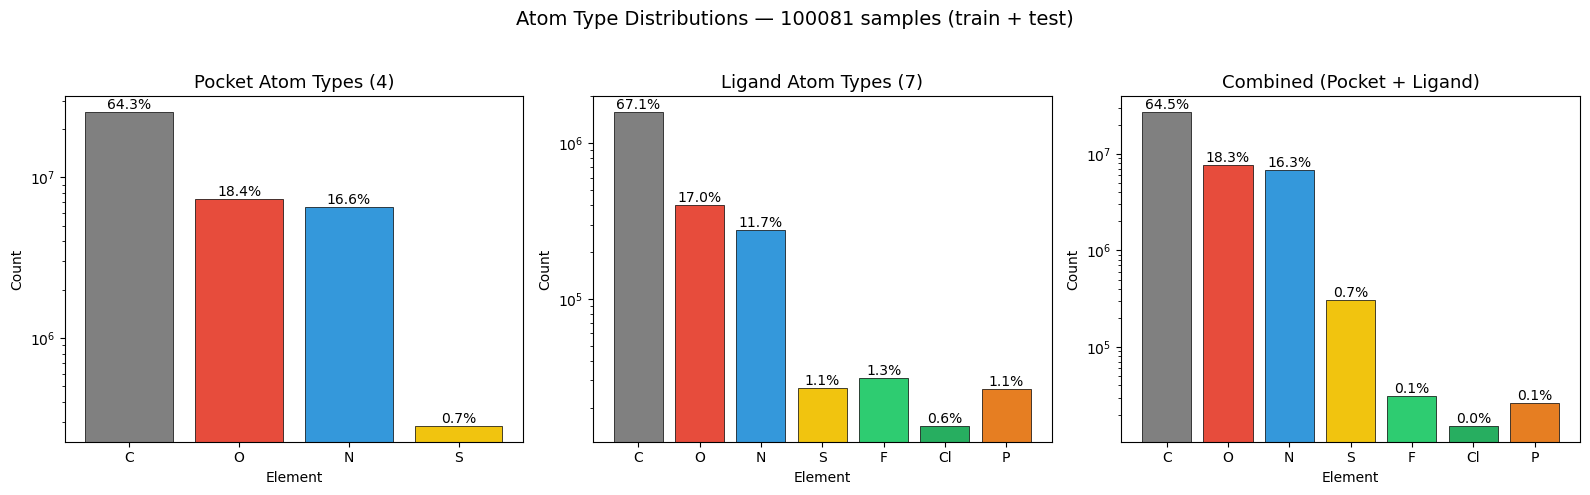

In [20]:
ELEM_COLORS = {"C": "#808080", "O": "#e74c3c", "N": "#3498db", "S": "#f1c40f", "F": "#2ecc71", "Cl": "#27ae60", "P": "#e67e22"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Pocket ────────────────────────────────────────────────────────────
poc_pct = poc_counts / poc_counts.sum() * 100
colors_poc = [ELEM_COLORS[e] for e in POCKET_ELEMS]
bars = axes[0].bar(POCKET_ELEMS, poc_counts, color=colors_poc, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, poc_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log")
axes[0].set_title("Pocket Atom Types (4)", fontsize=13)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Element")

# ── Ligand ────────────────────────────────────────────────────────────
lig_pct = lig_counts / lig_counts.sum() * 100
colors_lig = [ELEM_COLORS[e] for e in LIGAND_ELEMS]
bars = axes[1].bar(LIGAND_ELEMS, lig_counts, color=colors_lig, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, lig_pct):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_yscale("log")
axes[1].set_title("Ligand Atom Types (7)", fontsize=13)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Element")

# ── Combined ──────────────────────────────────────────────────────────
all_elems = LIGAND_ELEMS  # superset (7 elements)
comb_counts = np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64)
for i in range(N_POCKET_ELEMENTS):
    comb_counts[i] += poc_counts[i]
for i in range(N_LIGAND_ELEMENTS):
    comb_counts[i] += lig_counts[i]

comb_pct = comb_counts / comb_counts.sum() * 100
colors_all = [ELEM_COLORS[e] for e in all_elems]
bars = axes[2].bar(all_elems, comb_counts, color=colors_all, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, comb_pct):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[2].set_yscale("log")
axes[2].set_title("Combined (Pocket + Ligand)", fontsize=13)
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Element")

fig.suptitle(f"Atom Type Distributions — {len(data_all)} samples (train + test)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Generated samples — VoxBind (cbgbench)

Atom type distribution from the **generated** ligand SDF files under `exps/cbgbench/voxbind/`, compared with the **dataset** ligand distribution.

In [21]:
from glob import glob
from rdkit import Chem
from collections import Counter

GEN_DIR = os.path.join(os.getcwd(), "..", "voxbind", "exps", "cbgbench", "voxbind")
sdf_files = sorted(glob(os.path.join(GEN_DIR, "**", "samples_*.sdf"), recursive=True))
print(f"Found {len(sdf_files)} generated SDF files")

# count atoms by element symbol
gen_elem_counter = Counter()
n_parsed = 0
for sdf_path in sdf_files:
    try:
        suppl = Chem.SDMolSupplier(sdf_path, sanitize=False, removeHs=True)
        for mol in suppl:
            if mol is None:
                continue
            for atom in mol.GetAtoms():
                gen_elem_counter[atom.GetSymbol()] += 1
            n_parsed += 1
    except Exception:
        continue

print(f"Parsed {n_parsed} molecules")
print(f"Atom counts: {dict(gen_elem_counter.most_common())}")

Found 6651 generated SDF files


[06:07:23] atom 15 has specified valence (1) smaller than the drawn valence 2.
[06:07:23] atom 22 has specified valence (3) smaller than the drawn valence 4.
[06:07:23] atom 19 has specified valence (1) smaller than the drawn valence 2.
[06:07:23] atom 13 has specified valence (3) smaller than the drawn valence 4.
[06:07:23] atom 2 has specified valence (1) smaller than the drawn valence 2.
[06:07:23] atom 6 has specified valence (4) smaller than the drawn valence 5.
[06:07:23] atom 0 has specified valence (1) smaller than the drawn valence 2.
[06:07:23] atom 2 has specified valence (1) smaller than the drawn valence 2.
[06:07:23] atom 7 has specified valence (4) smaller than the drawn valence 5.
[06:07:23] atom 8 has specified valence (4) smaller than the drawn valence 5.
[06:07:23] atom 7 has specified valence (1) smaller than the drawn valence 2.
[06:07:23] atom 13 has specified valence (4) smaller than the drawn valence 5.
[06:07:23] atom 3 has specified valence (1) smaller than th

Parsed 6650 molecules
Atom counts: {'C': 109859, 'O': 20751, 'N': 16168, 'S': 1792, 'P': 693, 'Cl': 11}


[06:07:24] atom 5 has specified valence (1) smaller than the drawn valence 2.
[06:07:24] atom 6 has specified valence (3) smaller than the drawn valence 4.
[06:07:24] atom 15 has specified valence (1) smaller than the drawn valence 2.
[06:07:24] atom 20 has specified valence (4) smaller than the drawn valence 5.
[06:07:24] atom 26 has specified valence (1) smaller than the drawn valence 2.
[06:07:24] atom 33 has specified valence (4) smaller than the drawn valence 5.
[06:07:24] atom 27 has specified valence (1) smaller than the drawn valence 2.
[06:07:24] atom 32 has specified valence (3) smaller than the drawn valence 4.
[06:07:24] atom 24 has specified valence (1) smaller than the drawn valence 2.
[06:07:24] atom 30 has specified valence (3) smaller than the drawn valence 4.
[06:07:24] atom 19 has specified valence (1) smaller than the drawn valence 2.
[06:07:24] atom 25 has specified valence (3) smaller than the drawn valence 4.
[06:07:24] atom 14 has specified valence (1) smaller t

In [22]:
# ── Map generated counts to the same 7-element order as the dataset ───
gen_lig_counts = np.array([gen_elem_counter.get(e, 0) for e in LIGAND_ELEMS], dtype=np.int64)

# also report any unexpected elements
known = set(LIGAND_ELEMS)
extra = {k: v for k, v in gen_elem_counter.items() if k not in known}
if extra:
    print(f"Extra elements in generated (not in ligand channels): {extra}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: generated ligand distribution ───────────────────────────────
gen_pct = gen_lig_counts / gen_lig_counts.sum() * 100
colors_lig = [ELEM_COLORS[e] for e in LIGAND_ELEMS]
bars = axes[0].bar(LIGAND_ELEMS, gen_lig_counts, color=colors_lig, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, gen_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log")
axes[0].set_title(f"Generated Ligands ({n_parsed} mols)", fontsize=13)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Element")

# ── Right: side-by-side comparison (dataset vs generated, normalised) ─
x = np.arange(len(LIGAND_ELEMS))
w = 0.35
dataset_pct = lig_counts / lig_counts.sum() * 100

bars1 = axes[1].bar(x - w/2, dataset_pct, w, color=[ELEM_COLORS[e] for e in LIGAND_ELEMS], edgecolor="black", linewidth=0.5, label="Dataset")
bars2 = axes[1].bar(x + w/2, gen_pct, w, color=[ELEM_COLORS[e] for e in LIGAND_ELEMS], edgecolor="black", linewidth=0.5, alpha=0.55, label="Generated", hatch="//")
axes[1].set_xticks(x)
axes[1].set_xticklabels(LIGAND_ELEMS)
axes[1].set_yscale("log")
axes[1].set_title("Dataset vs Generated (normalised %)", fontsize=13)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("Element")
axes[1].legend(fontsize=11)

fig.suptitle("Ligand Atom Type Distribution — Dataset vs Generated (cbgbench)", fontsize=14)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [23]:
sdf

NameError: name 'sdf' is not defined